In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =============================================================================
# phase2b_rl_colab.py — Google Colab
# Q-Learning figures + results table
#
# UPLOAD THESE FILES to Colab_Final\ then upload ALL to Colab:
#   demand_nodes.csv
#   distance_matrix_network.csv
#   cplex_results.json            ← from CPLEX_LP\CPLEX_Outputs\
#   cplex_assignments_p5/8/10.csv ← from CPLEX_LP\CPLEX_Outputs\
#   pulp_results.json             ← from PuLP_Outputs\
#   pulp_assignments_p5/8/10.csv  ← from PuLP_Outputs\
#
# THREE-WAY COMPARISON:
#   CPLEX     — exact optimum on 39 aggregated clusters (license-constrained)
#   PuLP/CBC  — exact optimum on full 733 demand nodes (no aggregation)
#   Q-Learning — learned solution on full 733 demand nodes
#
# No installs needed — pure numpy / pandas / matplotlib
# =============================================================================


# ════════════════════════════════════════════════════════════════════════════
# CELL 1 — Setup: libraries + candidate shelters
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, random, json

candidates_data = [
    {"SID": 0,  "NAME": "Clearwater Fundamental Middle",       "LAT": 27.976248, "LON": -82.766487},
    {"SID": 1,  "NAME": "Palm Harbor Middle",                  "LAT": 28.066762, "LON": -82.752829},
    {"SID": 2,  "NAME": "John Hopkins Middle",                 "LAT": 27.763104, "LON": -82.656309},
    {"SID": 3,  "NAME": "Sexton Elementary",                   "LAT": 27.822357, "LON": -82.659844},
    {"SID": 4,  "NAME": "Gibbs High",                          "LAT": 27.761577, "LON": -82.678299},
    {"SID": 5,  "NAME": "McMullen-Booth Elementary",           "LAT": 27.995527, "LON": -82.712017},
    {"SID": 6,  "NAME": "Carwise Middle",                      "LAT": 28.088628, "LON": -82.726590},
    {"SID": 7,  "NAME": "Jamerson Elementary",                 "LAT": 27.758239, "LON": -82.682283},
    {"SID": 8,  "NAME": "Sanderlin K-8",                       "LAT": 27.747297, "LON": -82.665967},
    {"SID": 9,  "NAME": "Ross Norton",                         "LAT": 27.945113, "LON": -82.793368},
    {"SID": 10, "NAME": "Campbell Park Elementary",            "LAT": 27.763674, "LON": -82.649600},
    {"SID": 11, "NAME": "New Heights Elementary",              "LAT": 27.807558, "LON": -82.682420},
    {"SID": 12, "NAME": "Fairmount Park Elementary",           "LAT": 27.764914, "LON": -82.690303},
    {"SID": 13, "NAME": "Belleair Elementary",                 "LAT": 27.950563, "LON": -82.788892},
    {"SID": 14, "NAME": "Skycrest Elementary",                 "LAT": 27.966234, "LON": -82.761041},
    {"SID": 15, "NAME": "Largo High",                          "LAT": 27.919742, "LON": -82.786281},
    {"SID": 16, "NAME": "Lealman Exchange",                    "LAT": 27.818585, "LON": -82.693162},
    {"SID": 17, "NAME": "Mildred Helms Elementary",            "LAT": 27.912518, "LON": -82.797080},
    {"SID": 18, "NAME": "Melrose Elementary",                  "LAT": 27.757180, "LON": -82.657401},
    {"SID": 19, "NAME": "Palm Harbor University High",         "LAT": 28.085000, "LON": -82.760587},
    {"SID": 20, "NAME": "Palm Harbor University High Bldg 19", "LAT": 28.084940, "LON": -82.760508},
    {"SID": 21, "NAME": "Clearwater High",                     "LAT": 27.959558, "LON": -82.756357},
    {"SID": 22, "NAME": "Palm Harbor CSA",                     "LAT": 28.081885, "LON": -82.757176},
    {"SID": 23, "NAME": "The Coliseum",                        "LAT": 27.776730, "LON": -82.641115},
    {"SID": 24, "NAME": "White Chapel",                        "LAT": 28.076766, "LON": -82.765247},
]
candidates = pd.DataFrame(candidates_data)
P_VALUES   = [5, 8, 10]
print(f"Candidates: {len(candidates)}  |  p values: {P_VALUES}")

Candidates: 25  |  p values: [5, 8, 10]


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 — Load data + CPLEX + PuLP results
# ════════════════════════════════════════════════════════════════════════════
demand = pd.read_csv("/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/demand_nodes.csv", dtype={"GEOID_JOIN": str})
demand["GEOID_JOIN"] = demand["GEOID_JOIN"].str.replace(r"\.0$", "", regex=True)

matrix_raw = pd.read_csv("/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/distance_matrix_network.csv", index_col=0, dtype={0: str})
matrix_raw.index = matrix_raw.index.astype(str).str.replace(r"\.0$", "", regex=True)
D = matrix_raw.values.astype(float)
W = demand["WEIGHTED_DEMAND"].values

print(f"Demand nodes:          {len(demand)}")
print(f"Total weighted demand: {W.sum():,.1f}")
print(f"Distance matrix:       {D.shape}  (travel time, minutes)")

# Load CPLEX results (39-cluster aggregated)
with open("/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/cplex_results.json") as f:
    cplex_json = json.load(f)

cplex_results = {}
for p in P_VALUES:
    c        = cplex_json[str(p)]
    asgn_df  = pd.read_csv(f"/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/cplex_assignments_p{p}.csv", dtype={"GEOID_JOIN": str})
    cplex_results[p] = {
        "p":          p,
        "objective":  c["objective"],
        "solve_time": c["solve_time"],
        "selected":   c["selected"],
        "assignments": asgn_df["ASSIGNED_SID"].tolist(),
    }

# Load PuLP results (full 733 BGs)
with open("/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/pulp_results.json") as f:
    pulp_json = json.load(f)

pulp_results_loaded = {}
for p in P_VALUES:
    pl       = pulp_json[str(p)]
    asgn_df  = pd.read_csv(f"/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/pulp_assignments_p{p}.csv", dtype={"GEOID_JOIN": str})
    pulp_results_loaded[p] = {
        "p":          p,
        "objective":  pl["objective"],
        "solve_time": pl["solve_time"],
        "selected":   pl["selected"],
        "assignments": asgn_df["ASSIGNED_SID"].tolist(),
    }

print(f"\n{'Method':<12} {'p':>4}  {'Objective':>16}  {'Time(s)':>9}  Selected shelters")
print("─" * 80)
for p in P_VALUES:
    c  = cplex_results[p]
    pl = pulp_results_loaded[p]
    agg_error = 100*(c["objective"] - pl["objective"]) / pl["objective"]
    print(f"{'CPLEX':<12} {p:>4}  {c['objective']:>16,.2f}  {c['solve_time']:>9.2f}"
          f"  {[candidates.iloc[j]['NAME'][:20] for j in c['selected']]}")
    print(f"{'PuLP/CBC':<12} {p:>4}  {pl['objective']:>16,.2f}  {pl['solve_time']:>9.1f}"
          f"  {[candidates.iloc[j]['NAME'][:20] for j in pl['selected']]}")
    print(f"  Aggregation error: {agg_error:+.2f}%")
    print()
# Load CPLEX Full results (full 733-node, full licence — from Dr. Downs)
# Actual solve times from lpresults.txt: p5=1.09s, p8=1.10s, p10=1.20s
CPLEX_FULL_TIMES = {5: 1.09, 8: 1.10, 10: 1.20}

with open("/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/cplex_full_results.json") as f:
    cplex_full_json = json.load(f)

cplex_full_results = {}
for p in P_VALUES:
    cf       = cplex_full_json[str(p)]
    asgn_df  = pd.read_csv(f"/content/drive/MyDrive/USF_Spring26_GIS_Seminar/Data_input/cplex_full_assignments_p{p}.csv",
                           dtype={"GEOID_JOIN": str})
    cplex_full_results[p] = {
        "p":          p,
        "objective":  cf["objective"],
        "solve_time": CPLEX_FULL_TIMES[p],   # actual times from lpresults.txt
        "selected":   cf["selected"],
        "assignments": asgn_df["ASSIGNED_SID"].tolist(),
    }

print("\nCPLEX Full (733-node, full licence) results:")
for p in P_VALUES:
    cf  = cplex_full_results[p]
    pl  = pulp_results_loaded[p]
    gap = 100*(cf["objective"] - pl["objective"]) / pl["objective"]
    print(f"  p={p}: Obj={cf['objective']:,.2f}  Gap={gap:+.4f}%  Time={cf['solve_time']}s  Shelters={cf['selected']}")


Demand nodes:          733
Total weighted demand: 570,579.9
Distance matrix:       (733, 25)  (travel time, minutes)

Method          p         Objective    Time(s)  Selected shelters
────────────────────────────────────────────────────────────────────────────────
CPLEX           5      4,140,078.06       0.00  ['Clearwater Fundament', 'Palm Harbor Middle', 'Jamerson Elementary', 'Lealman Exchange', 'Mildred Helms Elemen']
PuLP/CBC        5      4,184,071.38        7.4  ['Palm Harbor Middle', 'Sanderlin K-8', 'Skycrest Elementary', 'Lealman Exchange', 'Mildred Helms Elemen']
  Aggregation error: -1.05%

CPLEX           8      3,742,283.83       0.00  ['Clearwater Fundament', 'Palm Harbor Middle', 'Sexton Elementary', 'McMullen-Booth Eleme', 'Sanderlin K-8', 'Fairmount Park Eleme', 'Lealman Exchange', 'Mildred Helms Elemen']
PuLP/CBC        8      3,774,238.41       28.2  ['Clearwater Fundament', 'Palm Harbor Middle', 'Sexton Elementary', 'McMullen-Booth Eleme', 'Sanderlin K-8', 'Fairmo

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 — Q-Learning (on full 733 demand nodes)
# ════════════════════════════════════════════════════════════════════════════
def compute_objective(config, W, D):
    sub = D[:, list(config)]
    return float(np.dot(W, sub.min(axis=1)))

def q_learning(W, D, p, n_episodes=3000, max_steps=300,
               alpha=0.1, gamma=0.95,
               eps_start=1.0, eps_end=0.05, eps_decay=0.997, seed=42):
    random.seed(seed); np.random.seed(seed)
    n_J = D.shape[1]
    Q   = {}

    def qval(s, a):  return Q.get((s, a), 0.0)
    def actions(s):
        op = list(s); cl = [j for j in range(n_J) if j not in s]
        return [(o, c) for o in op for c in cl]
    def step(s, a):
        ns = set(s); ns.discard(a[0]); ns.add(a[1]); return frozenset(ns)

    best_cfg    = frozenset(random.sample(range(n_J), p))
    best_obj    = compute_objective(best_cfg, W, D)
    eps         = eps_start
    best_per_ep = []

    for ep in range(n_episodes):
        s     = frozenset(random.sample(range(n_J), p))
        s_obj = compute_objective(s, W, D)

        for _ in range(max_steps):
            acts   = actions(s)
            a      = random.choice(acts) if random.random() < eps \
                     else max(acts, key=lambda a: qval(s, a))
            ns     = step(s, a)
            ns_obj = compute_objective(ns, W, D)
            reward = s_obj - ns_obj

            best_next = max((qval(ns, na) for na in actions(ns)), default=0.0)
            Q[(s, a)] = qval(s, a) + alpha*(reward + gamma*best_next - qval(s, a))
            s, s_obj  = ns, ns_obj
            if s_obj < best_obj:
                best_obj, best_cfg = s_obj, s

        best_per_ep.append(best_obj)
        eps = max(eps_end, eps * eps_decay)

    selected    = sorted(best_cfg)
    sub          = D[:, selected]
    assignments = [selected[k] for k in sub.argmin(axis=1)]
    return {
        "p": p, "objective": best_obj, "selected": selected,
        "assignments": assignments, "best_per_ep": best_per_ep
    }

rl_results = {}
print("Running Q-Learning (full 733 BGs)...\n" + "─"*60)
for p in P_VALUES:
    print(f"  p = {p} ...", end=" ", flush=True)
    t0  = time.time()
    res = q_learning(W, D, p)
    res["train_time"] = time.time() - t0
    rl_results[p]     = res
    # Gap vs PuLP (the unconstrained exact benchmark)
    gap = 100*(res["objective"] - pulp_results_loaded[p]["objective"]) \
              / pulp_results_loaded[p]["objective"]
    print(f"Obj: {res['objective']:,.2f}  |  Gap vs PuLP: {gap:.2f}%  "
          f"|  Time: {res['train_time']:.1f}s")
    for j in res["selected"]:
        print(f"      ✓ {candidates.iloc[j]['NAME']}")
    print()

import os
output_dir = "/content/drive/MyDrive/USF_Spring26_GIS_Seminar/RL_Output"
os.makedirs(output_dir, exist_ok=True)

for p, res in rl_results.items():
    out = demand[["GEOID_JOIN","LAT","LON","POPULATION","WEIGHTED_DEMAND"]].copy()
    out["METHOD"]          = "RL"
    out["ASSIGNED_SID"]    = res["assignments"]
    out["ASSIGNED_NAME"]   = [candidates.iloc[j]["NAME"] for j in res["assignments"]]
    out["TRAVEL_TIME_MIN"] = [D[i, res["assignments"][i]] for i in range(len(demand))]
    out.to_csv(f"{output_dir}/rl_assignments_p{p}.csv", index=False)
print("RL assignment CSVs saved.")

Running Q-Learning (full 733 BGs)...
────────────────────────────────────────────────────────────
  p = 5 ... Obj: 4,184,071.38  |  Gap vs PuLP: 0.00%  |  Time: 118.7s
      ✓ Palm Harbor Middle
      ✓ Sanderlin K-8
      ✓ Skycrest Elementary
      ✓ Lealman Exchange
      ✓ Mildred Helms Elementary

  p = 8 ... Obj: 3,782,699.13  |  Gap vs PuLP: 0.22%  |  Time: 116.3s
      ✓ Clearwater Fundamental Middle
      ✓ Palm Harbor Middle
      ✓ Sexton Elementary
      ✓ McMullen-Booth Elementary
      ✓ Jamerson Elementary
      ✓ Lealman Exchange
      ✓ Mildred Helms Elementary
      ✓ The Coliseum

  p = 10 ... Obj: 3,652,908.77  |  Gap vs PuLP: 0.31%  |  Time: 124.1s
      ✓ Clearwater Fundamental Middle
      ✓ Sexton Elementary
      ✓ McMullen-Booth Elementary
      ✓ Carwise Middle
      ✓ Jamerson Elementary
      ✓ Campbell Park Elementary
      ✓ Belleair Elementary
      ✓ Lealman Exchange
      ✓ Mildred Helms Elementary
      ✓ White Chapel

RL assignment CSVs saved.


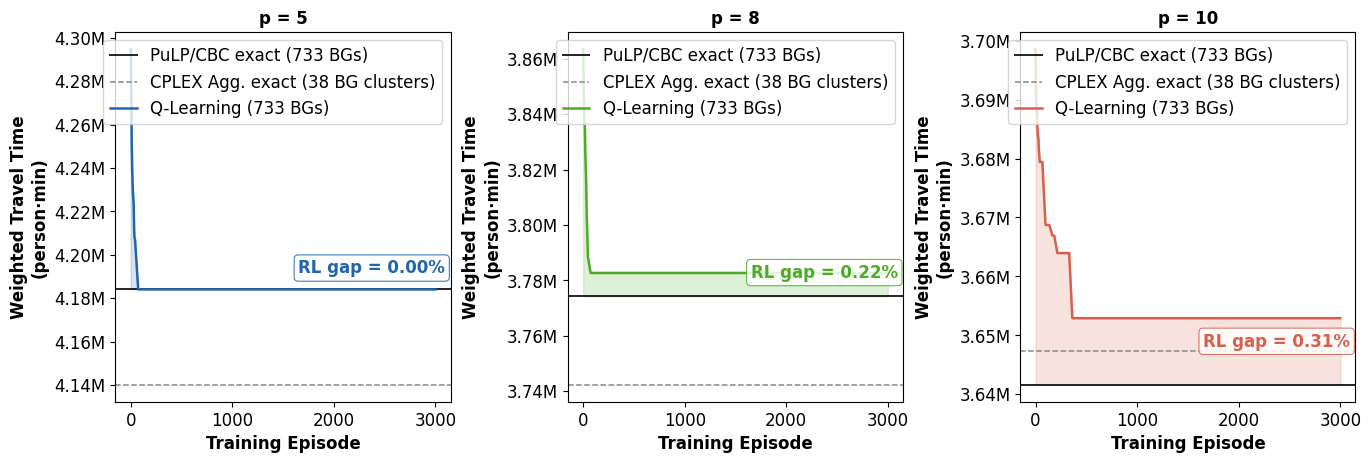

Saved fig1_convergence


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 — Figure 1: Q-Learning convergence  (publication quality)
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=False)
fig.subplots_adjust(wspace=0.35)

COL = {
    "cplex": "#2166ac",
    "pulp": "#4dac26",
    "rl": "#d6604d",
}
panel_colors = [COL["cplex"], COL["pulp"], COL["rl"]]

for ax, p, pc in zip(axes, P_VALUES, panel_colors):
    curve    = pd.Series(rl_results[p]["best_per_ep"]).rolling(30, min_periods=1).mean()
    pulp_val = pulp_results_loaded[p]["objective"]
    cplex_val= cplex_results[p]["objective"]
    gap      = 100*(rl_results[p]["objective"] - pulp_val) / pulp_val

    # Shaded gap region
    ax.fill_between(range(len(curve)), curve, pulp_val,
                    where=curve > pulp_val,
                    alpha=0.18, color=pc, zorder=1)

    # Reference lines first (behind curve)
    ax.axhline(pulp_val,  color="#222", lw=1.4, ls="-",  zorder=2,
               label="PuLP/CBC exact (733 BGs)")
    ax.axhline(cplex_val, color="#888", lw=1.1, ls="--", zorder=2,
               label="CPLEX Agg. exact (38 BG clusters)")

    # RL curve
    ax.plot(curve, color=pc, lw=1.8, zorder=3, label="Q-Learning (733 BGs)")

    # Gap annotation box
    ax.annotate(f"RL gap = {gap:.2f}%",
                xy=(len(curve)*0.97, rl_results[p]["objective"]),
                xytext=(len(curve)*0.55, pulp_val*1.0018),
                fontsize=12, color=pc, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white",
                          ec=pc, alpha=0.85, lw=0.8))

    ax.set_title(f"p = {p}", fontsize=12, fontweight="bold", pad=6)
    ax.set_xlabel("Training Episode", fontweight="bold", fontsize=12)
    ax.set_ylabel("Weighted Travel Time\n(person·min)", fontweight="bold", fontsize=12)

    # ---- MODIFICATION: Set tick label sizes to 12 ----
    ax.tick_params(axis='both', labelsize=12)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.2f}M"))
    ax.legend(loc="upper right", fontsize=12, handlelength=1.6)

'''fig.suptitle(
    "Q-Learning Convergence vs Exact Optima — Pinellas County, FL",
    fontsize=13, fontweight="bold", y=1.02)'''

for fmt in ["pdf", "png"]:
    # ---- MODIFICATION: Added dpi=600 parameter ----
    fig.savefig(os.path.join(output_dir, f"fig1_convergence.{fmt}"), dpi=600)
plt.show()
print("Saved fig1_convergence")

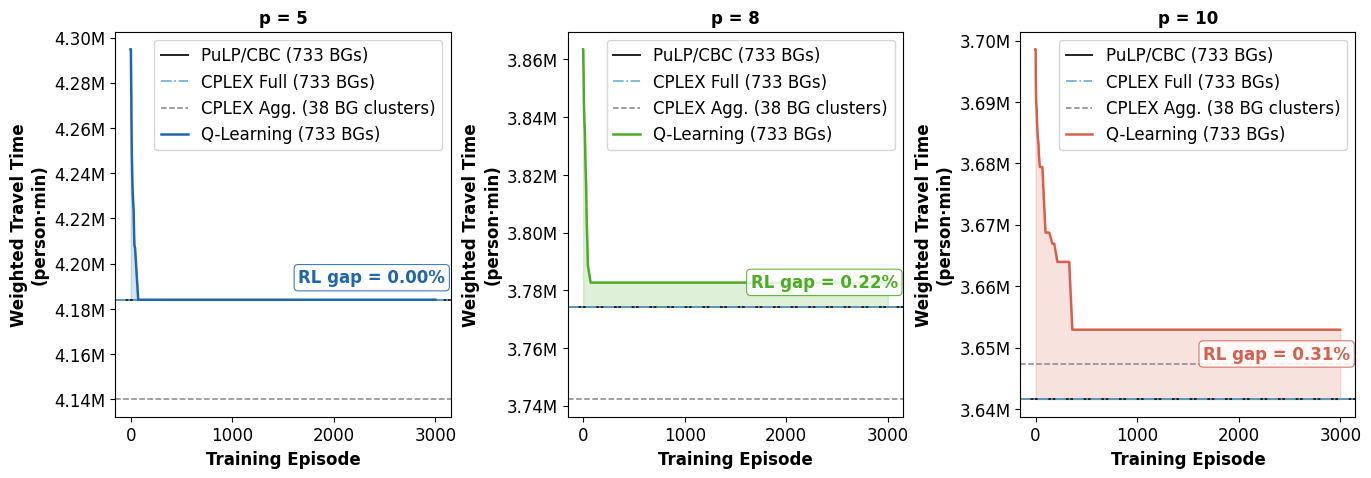

Saved fig1_convergence


In [28]:
import matplotlib.ticker as mticker

# ════════════════════════════════════════════════════════════════════════════
# CELL 4 — Figure 1: Q-Learning convergence  (publication quality)
# Now includes CPLEX Full (733-node, full licence) as a reference line
# ════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.subplots_adjust(wspace=0.35)

COL = {
    "cplex":      "#2166ac",   # dark blue  — CPLEX aggregated
    "cplex_full": "#6baed6",   # light blue — CPLEX Full (new)
    "pulp":       "#4dac26",   # green      — PuLP/CBC
    "rl":         "#d6604d",   # red/orange — Q-Learning
}
panel_colors = [COL["cplex"], COL["pulp"], COL["rl"]]

for ax, p, pc in zip(axes, P_VALUES, panel_colors):
    curve         = pd.Series(rl_results[p]["best_per_ep"]).rolling(30, min_periods=1).mean()
    pulp_val      = pulp_results_loaded[p]["objective"]
    cplex_val     = cplex_results[p]["objective"]
    cplex_full_val= cplex_full_results[p]["objective"]   # NEW
    gap           = 100*(rl_results[p]["objective"] - pulp_val) / pulp_val

    # Shaded gap region
    ax.fill_between(range(len(curve)), curve, pulp_val,
                    where=curve > pulp_val,
                    alpha=0.18, color=pc, zorder=1)

    # Reference lines (drawn behind the RL curve)
    ax.axhline(pulp_val,       color="#222",           lw=1.4, ls="-",  zorder=2,
               label="PuLP/CBC (733 BGs)")
    ax.axhline(cplex_full_val, color=COL["cplex_full"],lw=1.2, ls="-.", zorder=2,
               label="CPLEX Full (733 BGs)")   # NEW — dash-dot line
    ax.axhline(cplex_val,      color="#888",            lw=1.1, ls="--", zorder=2,
               label="CPLEX Agg. (38 BG clusters)")

    # RL curve
    ax.plot(curve, color=pc, lw=1.8, zorder=3, label="Q-Learning (733 BGs)")

    # Gap annotation box
    ax.annotate(f"RL gap = {gap:.2f}%",
                xy=(len(curve)*0.97, rl_results[p]["objective"]),
                xytext=(len(curve)*0.55, pulp_val*1.0018),
                fontsize=12, color=pc, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white",
                          ec=pc, alpha=0.85, lw=0.8))

    ax.set_title(f"p = {p}", fontsize=12, fontweight="bold", pad=6)
    ax.set_xlabel("Training Episode", fontweight="bold", fontsize=12)
    ax.set_ylabel("Weighted Travel Time\n(person·min)", fontweight="bold", fontsize=12)
    ax.tick_params(axis='both', labelsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.2f}M"))
    ax.legend(loc="upper right", fontsize=12, handlelength=1.6)

'''fig.suptitle(
    "Q-Learning Convergence vs Exact Optima — Pinellas County, FL",
    fontsize=13, fontweight="bold", y=1.02)'''

for fmt in ["pdf", "png", "jpg", "svg"]:
    fig.savefig(os.path.join(output_dir, f"fig1_convergence.{fmt}"), dpi=600)
plt.show()
print("Saved fig1_convergence")

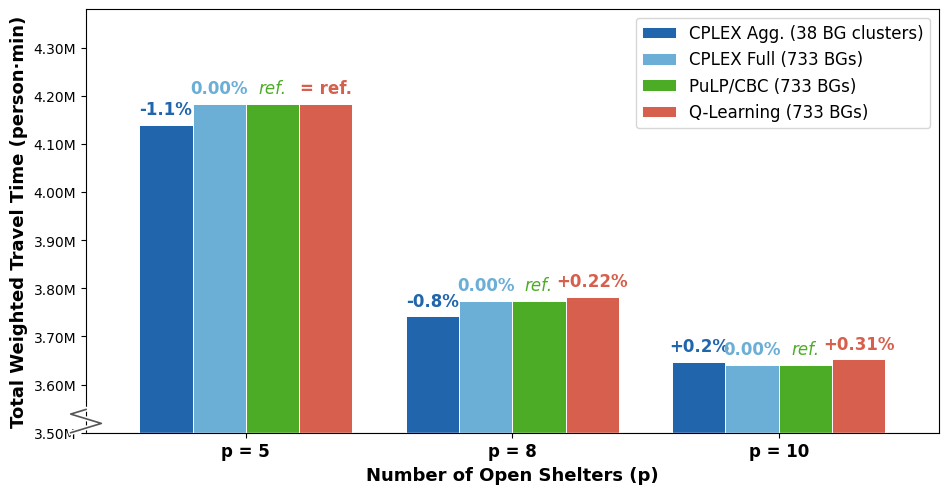

Saved fig2_objective_comparison  (4-way)


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 — Figure 2: Four-way solution quality  (publication quality)
# Y-axis starts at 3.5M. Four bars per group: CPLEX Agg, CPLEX Full, PuLP/CBC, Q-Learning
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.ticker as mticker

COL = {
    "cplex":      "#2166ac",   # dark blue  — CPLEX aggregated
    "cplex_full": "#6baed6",   # light blue — CPLEX Full
    "pulp":       "#4dac26",   # green      — PuLP/CBC benchmark
    "rl":         "#d6604d",   # red        — Q-Learning
}

fig, ax = plt.subplots(figsize=(11, 5.5))

x  = np.arange(len(P_VALUES))
w  = 0.20   # bar width — 4 bars fit cleanly

c_objs   = [cplex_results[p]["objective"]      for p in P_VALUES]
cf_objs  = [cplex_full_results[p]["objective"] for p in P_VALUES]
pl_objs  = [pulp_results_loaded[p]["objective"]     for p in P_VALUES]
r_objs   = [rl_results[p]["objective"]         for p in P_VALUES]

Y_MIN = 3_500_000
Y_MAX = max(c_objs) * 1.058

b1 = ax.bar(x - 1.5*w, [v - Y_MIN for v in c_objs],  w,
            bottom=Y_MIN, color=COL["cplex"],      label="CPLEX Agg. (38 BG clusters)",
            edgecolor="white", linewidth=0.7, zorder=3)
b2 = ax.bar(x - 0.5*w, [v - Y_MIN for v in cf_objs], w,
            bottom=Y_MIN, color=COL["cplex_full"], label="CPLEX Full (733 BGs)",
            edgecolor="white", linewidth=0.7, zorder=3)
b3 = ax.bar(x + 0.5*w, [v - Y_MIN for v in pl_objs], w,
            bottom=Y_MIN, color=COL["pulp"],       label="PuLP/CBC (733 BGs)",
            edgecolor="white", linewidth=0.7, zorder=3)
b4 = ax.bar(x + 1.5*w, [v - Y_MIN for v in r_objs],  w,
            bottom=Y_MIN, color=COL["rl"],         label="Q-Learning (733 BGs)",
            edgecolor="white", linewidth=0.7, zorder=3)

# Labels above each bar
label_offset = (Y_MAX - Y_MIN) * 0.015
for i, p in enumerate(P_VALUES):
    agg  = 100*(c_objs[i]  - pl_objs[i]) / pl_objs[i]
    cf_g = 100*(cf_objs[i] - pl_objs[i]) / pl_objs[i]
    rl_g = 100*(r_objs[i]  - pl_objs[i]) / pl_objs[i]

    ax.text(x[i] - 1.5*w, c_objs[i]  + label_offset, f"{agg:+.1f}%",
            ha="center", va="bottom", fontsize=12, color=COL["cplex"], fontweight="bold")
    ax.text(x[i] - 0.5*w, cf_objs[i] + label_offset,
            "0.00%" if abs(cf_g) < 0.001 else f"{cf_g:+.2f}%",
            ha="center", va="bottom", fontsize=12, color=COL["cplex_full"], fontweight="bold")
    ax.text(x[i] + 0.5*w, pl_objs[i] + label_offset, "ref.",
            ha="center", va="bottom", fontsize=12, color=COL["pulp"], fontstyle="italic")
    rl_lbl = "= ref." if abs(rl_g) < 0.01 else f"+{rl_g:.2f}%"
    ax.text(x[i] + 1.5*w, r_objs[i]  + label_offset, rl_lbl,
            ha="center", va="bottom", fontsize=12, color=COL["rl"], fontweight="bold")

# Axis formatting
ax.set_xlim(-0.6, len(P_VALUES) - 0.4)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xticks(x)
ax.set_xticklabels([f"p = {p}" for p in P_VALUES], fontweight="bold", fontsize=12)
ax.set_xlabel("Number of Open Shelters (p)", fontweight="bold", fontsize=13)
ax.set_ylabel("Total Weighted Travel Time (person·min)", fontweight="bold", fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))

# Axis-break zigzag
spine_x = ax.get_xlim()[0]
zig_y   = Y_MIN
zig_h   = (Y_MAX - Y_MIN) * 0.022
zig_w   = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.018
zx = [spine_x-zig_w, spine_x, spine_x+zig_w, spine_x, spine_x-zig_w, spine_x]
zy = [zig_y, zig_y+zig_h*0.5, zig_y+zig_h, zig_y+zig_h*1.5, zig_y+zig_h*2, zig_y+zig_h*2.5]
ax.plot(zx, zy, color="white", lw=3.5, zorder=10, clip_on=False)
ax.plot(zx, zy, color="#555",  lw=1.2, zorder=11, clip_on=False)
ax.axhspan(Y_MIN-(Y_MAX-Y_MIN)*0.05, Y_MIN, color="white", zorder=8)
ax.axhline(Y_MIN, color="#555", lw=0.8, zorder=9)

ax.legend(fontsize=12, loc="upper right")

for fmt in ["pdf", "png"]:
    fig.savefig(os.path.join(output_dir, f"fig2_objective_comparison.{fmt}"),
                bbox_inches="tight", dpi=300)
plt.show()
print("Saved fig2_objective_comparison  (4-way)")


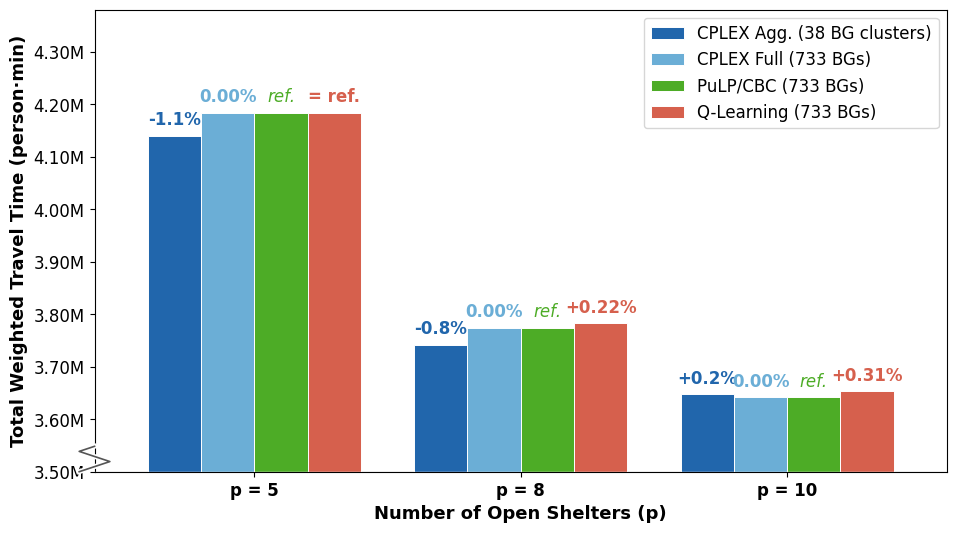

Saved fig2_objective_comparison  (4-way)


In [27]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 — Figure 2: Four-way solution quality  (publication quality)
# Y-axis starts at 3.5M. Four bars per group: CPLEX Agg, CPLEX Full, PuLP/CBC, Q-Learning
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.ticker as mticker

COL = {
    "cplex":       "#2166ac",   # dark blue  — CPLEX aggregated
    "cplex_full": "#6baed6",   # light blue — CPLEX Full
    "pulp":        "#4dac26",   # green      — PuLP/CBC benchmark
    "rl":          "#d6604d",   # red        — Q-Learning
}

fig, ax = plt.subplots(figsize=(11, 6))

x  = np.arange(len(P_VALUES))
w  = 0.20   # bar width — 4 bars fit cleanly

c_objs   = [cplex_results[p]["objective"]      for p in P_VALUES]
cf_objs  = [cplex_full_results[p]["objective"] for p in P_VALUES]
pl_objs  = [pulp_results_loaded[p]["objective"]     for p in P_VALUES]
r_objs   = [rl_results[p]["objective"]         for p in P_VALUES]

Y_MIN = 3_500_000
Y_MAX = max(c_objs) * 1.058

b1 = ax.bar(x - 1.5*w, [v - Y_MIN for v in c_objs],  w,
            bottom=Y_MIN, color=COL["cplex"],      label="CPLEX Agg. (38 BG clusters)",
            edgecolor="white", linewidth=0.7, zorder=3)
b2 = ax.bar(x - 0.5*w, [v - Y_MIN for v in cf_objs], w,
            bottom=Y_MIN, color=COL["cplex_full"], label="CPLEX Full (733 BGs)",
            edgecolor="white", linewidth=0.7, zorder=3)
b3 = ax.bar(x + 0.5*w, [v - Y_MIN for v in pl_objs], w,
            bottom=Y_MIN, color=COL["pulp"],       label="PuLP/CBC (733 BGs)",
            edgecolor="white", linewidth=0.7, zorder=3)
b4 = ax.bar(x + 1.5*w, [v - Y_MIN for v in r_objs],  w,
            bottom=Y_MIN, color=COL["rl"],         label="Q-Learning (733 BGs)",
            edgecolor="white", linewidth=0.7, zorder=3)

# Labels above each bar
label_offset = (Y_MAX - Y_MIN) * 0.015
for i, p in enumerate(P_VALUES):
    agg  = 100*(c_objs[i]  - pl_objs[i]) / pl_objs[i]
    cf_g = 100*(cf_objs[i] - pl_objs[i]) / pl_objs[i]
    rl_g = 100*(r_objs[i]  - pl_objs[i]) / pl_objs[i]

    ax.text(x[i] - 1.5*w, c_objs[i]  + label_offset, f"{agg:+.1f}%",
            ha="center", va="bottom", fontsize=12, color=COL["cplex"], fontweight="bold")
    ax.text(x[i] - 0.5*w, cf_objs[i] + label_offset,
            "0.00%" if abs(cf_g) < 0.001 else f"{cf_g:+.2f}%",
            ha="center", va="bottom", fontsize=12, color=COL["cplex_full"], fontweight="bold")
    ax.text(x[i] + 0.5*w, pl_objs[i] + label_offset, "ref.",
            ha="center", va="bottom", fontsize=12, color=COL["pulp"], fontstyle="italic")
    rl_lbl = "= ref." if abs(rl_g) < 0.01 else f"+{rl_g:.2f}%"
    ax.text(x[i] + 1.5*w, r_objs[i]  + label_offset, rl_lbl,
            ha="center", va="bottom", fontsize=12, color=COL["rl"], fontweight="bold")

# Axis formatting
ax.set_xlim(-0.6, len(P_VALUES) - 0.4)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xticks(x)
ax.set_xticklabels([f"p = {p}" for p in P_VALUES], fontweight="bold", fontsize=12)
ax.set_xlabel("Number of Open Shelters (p)", fontweight="bold", fontsize=13)
ax.set_ylabel("Total Weighted Travel Time (person·min)", fontweight="bold", fontsize=13)

# ---- MODIFICATION: Set tick label sizes to 12 for both axes ----
ax.tick_params(axis='both', labelsize=12)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))

# Axis-break zigzag
spine_x = ax.get_xlim()[0]
zig_y   = Y_MIN
zig_h   = (Y_MAX - Y_MIN) * 0.022
zig_w   = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.018
zx = [spine_x-zig_w, spine_x, spine_x+zig_w, spine_x, spine_x-zig_w, spine_x]
zy = [zig_y, zig_y+zig_h*0.5, zig_y+zig_h, zig_y+zig_h*1.5, zig_y+zig_h*2, zig_y+zig_h*2.5]
ax.plot(zx, zy, color="white", lw=3.5, zorder=10, clip_on=False)
ax.plot(zx, zy, color="#555",  lw=1.2, zorder=11, clip_on=False)
ax.axhspan(Y_MIN-(Y_MAX-Y_MIN)*0.05, Y_MIN, color="white", zorder=8)
ax.axhline(Y_MIN, color="#555", lw=0.8, zorder=9)

ax.legend(fontsize=12, loc="upper right")

for fmt in ["pdf", "png", "jpg", "svg"]:
    fig.savefig(os.path.join(output_dir, f"fig2_objective_comparison.{fmt}"),
                bbox_inches="tight", dpi=600)
plt.show()
print("Saved fig2_objective_comparison  (4-way)")

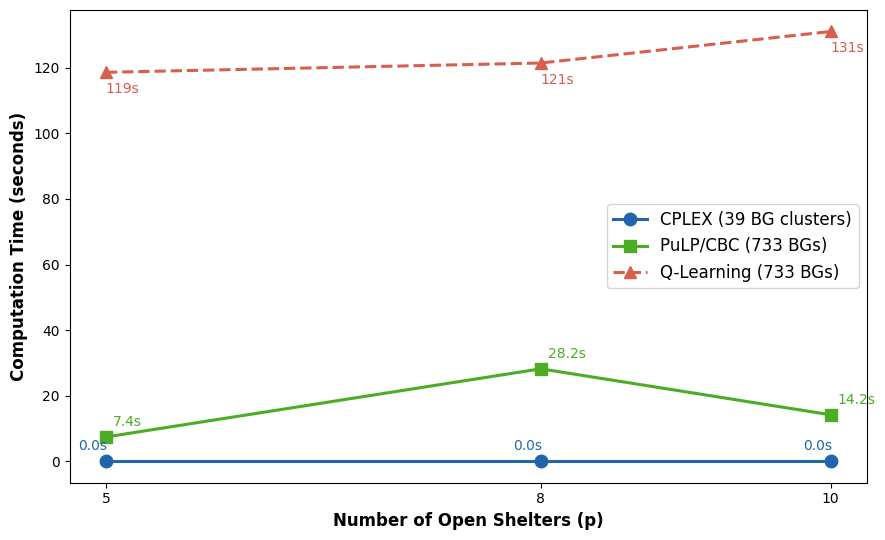

Saved: fig3_time_comparison.pdf / .png


In [31]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 — Figure 3: Computation time
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5.5))

c_times  = [cplex_results[p]["solve_time"]          for p in P_VALUES]
pl_times = [pulp_results_loaded[p]["solve_time"]     for p in P_VALUES]
r_times  = [rl_results[p]["train_time"]              for p in P_VALUES]

ax.plot(P_VALUES, c_times,  "o-",  color="#2166ac", lw=2.2, ms=9, label="CPLEX (39 BG clusters)")
ax.plot(P_VALUES, pl_times, "s-",  color="#4dac26", lw=2.2, ms=9, label="PuLP/CBC (733 BGs)")
ax.plot(P_VALUES, r_times,  "^--", color="#d6604d", lw=2.2, ms=9, label="Q-Learning (733 BGs)")

for p, ct, pt, rt in zip(P_VALUES, c_times, pl_times, r_times):
    ax.annotate(f"{ct:.1f}s",  (p, ct),  textcoords="offset points",
                xytext=(-20, 8),  fontsize=10, color="#2166ac")
    ax.annotate(f"{pt:.1f}s",  (p, pt),  textcoords="offset points",
                xytext=(5, 8),    fontsize=10, color="#4dac26")
    ax.annotate(f"{rt:.0f}s",  (p, rt),  textcoords="offset points",
                xytext=(0, -15),  fontsize=10, color="#d6604d")

ax.set_xticks(P_VALUES)
ax.set_xlabel("Number of Open Shelters (p)", fontsize=12, fontweight="bold")
ax.set_ylabel("Computation Time (seconds)", fontsize=12, fontweight="bold")
#ax.set_title("Computational Time: Three Methods", fontsize=12, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig3_time_comparison.pdf", bbox_inches="tight", dpi=300)
plt.savefig(f"{output_dir}/fig3_time_comparison.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved: fig3_time_comparison.pdf / .png")

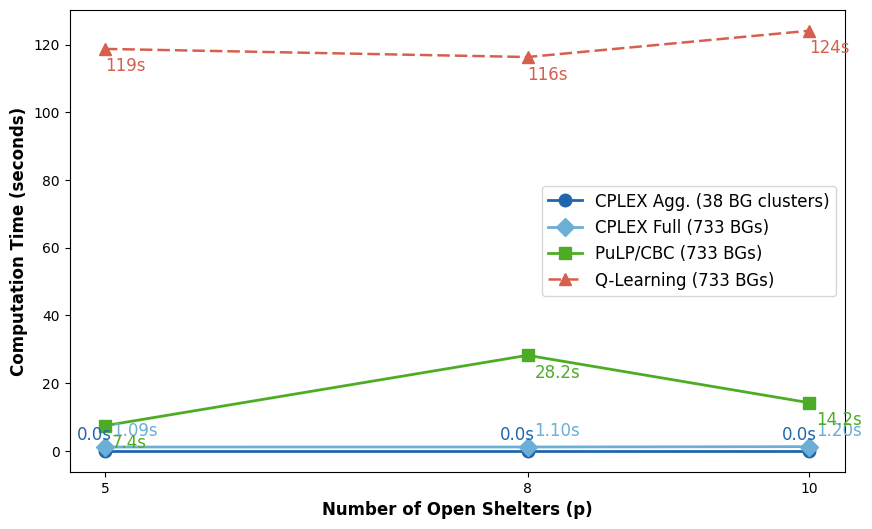

Saved fig3_time_comparison  (4 methods)


In [26]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 — Figure 3: Computation time  (publication quality, 4 methods)
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))

c_times  = [cplex_results[p]["solve_time"]      for p in P_VALUES]
cf_times = [cplex_full_results[p]["solve_time"] for p in P_VALUES]  # 1.09, 1.10, 1.20
pl_times = [pulp_results_loaded[p]["solve_time"]     for p in P_VALUES]
r_times  = [rl_results[p]["train_time"]         for p in P_VALUES]

ms = 9
ax.plot(P_VALUES, c_times,  "o-",  color=COL["cplex"],      lw=2,   ms=ms,
        label="CPLEX Agg. (38 BG clusters)", zorder=3)
ax.plot(P_VALUES, cf_times, "D-",  color=COL["cplex_full"], lw=2,   ms=ms,
        label="CPLEX Full (733 BGs)", zorder=3)
ax.plot(P_VALUES, pl_times, "s-",  color=COL["pulp"],       lw=2,   ms=ms,
        label="PuLP/CBC (733 BGs)", zorder=3)
ax.plot(P_VALUES, r_times,  "^--", color=COL["rl"],         lw=1.8, ms=ms,
        label="Q-Learning (733 BGs)", zorder=3, dashes=(5, 2))

# Annotate points
for p, ct, cft, pt, rt in zip(P_VALUES, c_times, cf_times, pl_times, r_times):
    ax.annotate(f"{ct:.1f}s",  (p, ct),  xytext=(-20, 8),  textcoords="offset points",
                fontsize=12, color=COL["cplex"])
    ax.annotate(f"{cft:.2f}s", (p, cft), xytext=(5, 8),    textcoords="offset points",
                fontsize=12, color=COL["cplex_full"])
    ax.annotate(f"{pt:.1f}s",  (p, pt),  xytext=(5, -16),  textcoords="offset points",
                fontsize=12, color=COL["pulp"])
    ax.annotate(f"{rt:.0f}s",  (p, rt),  xytext=(0, -16),  textcoords="offset points",
                fontsize=12, color=COL["rl"])

ax.set_xticks(P_VALUES)
ax.set_xlabel("Number of Open Shelters (p)", fontsize=12, fontweight="bold")
ax.set_ylabel("Computation Time (seconds)", fontsize=12, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(False)

for fmt in ["pdf", "png", "jpg", "svg"]:
    fig.savefig(os.path.join(output_dir, f"fig3_time_comparison.{fmt}"),
                bbox_inches="tight", dpi=600)
plt.show()
print("Saved fig3_time_comparison  (4 methods)")


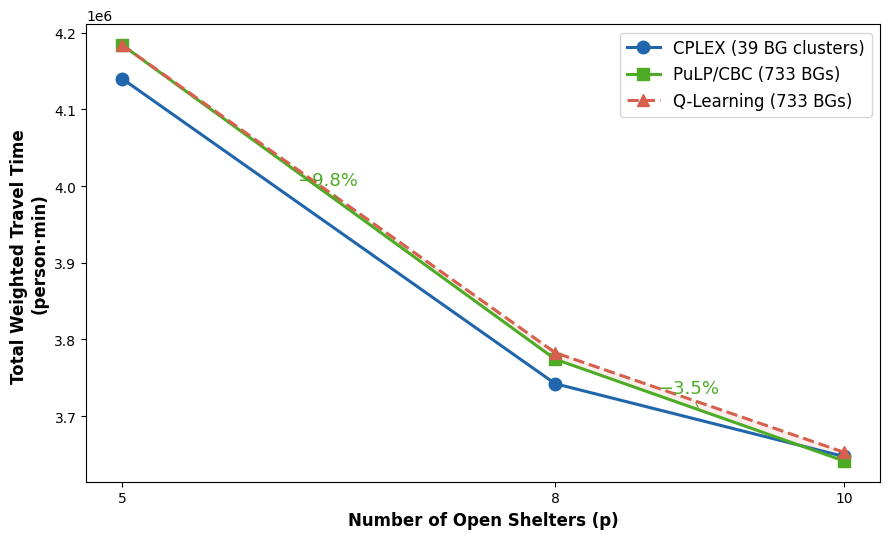

Saved: fig4_sensitivity.pdf / .png


In [29]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — Figure 4: Sensitivity analysis
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(P_VALUES, c_objs,  "o-",  color="#2166ac", lw=2.2, ms=9, label="CPLEX (39 BG clusters)")
ax.plot(P_VALUES, pl_objs, "s-",  color="#4dac26", lw=2.2, ms=9, label="PuLP/CBC (733 BGs)")
ax.plot(P_VALUES, r_objs,  "^--", color="#d6604d", lw=2.2, ms=9, label="Q-Learning (733 BGs)")
ax.fill_between(P_VALUES, pl_objs, r_objs, alpha=0.10, color="#d6604d")

for i in range(1, len(P_VALUES)):
    imp = 100*(pl_objs[i-1] - pl_objs[i]) / pl_objs[i-1]
    mid_x = (P_VALUES[i-1] + P_VALUES[i]) / 2
    mid_y = (pl_objs[i-1] + pl_objs[i]) / 2
    ax.annotate(f"−{imp:.1f}%", (mid_x, mid_y),
                textcoords="offset points", xytext=(-30, 12),
                fontsize=13, color="#4dac26",
                arrowprops=dict(arrowstyle="-", color="#4dac26", lw=0.8))

ax.set_xticks(P_VALUES)
ax.set_xlabel("Number of Open Shelters (p)", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Weighted Travel Time \n(person·min)", fontsize=12, fontweight="bold")
'''ax.set_title("Sensitivity: Objective vs p  (marginal improvement = PuLP/CBC)",
             fontsize=11, fontweight="bold")'''
ax.legend(fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig4_sensitivity.pdf", bbox_inches="tight", dpi=600)
plt.savefig(f"{output_dir}/fig4_sensitivity.png", bbox_inches="tight", dpi=600)
plt.show()
print("Saved: fig4_sensitivity.pdf / .png")

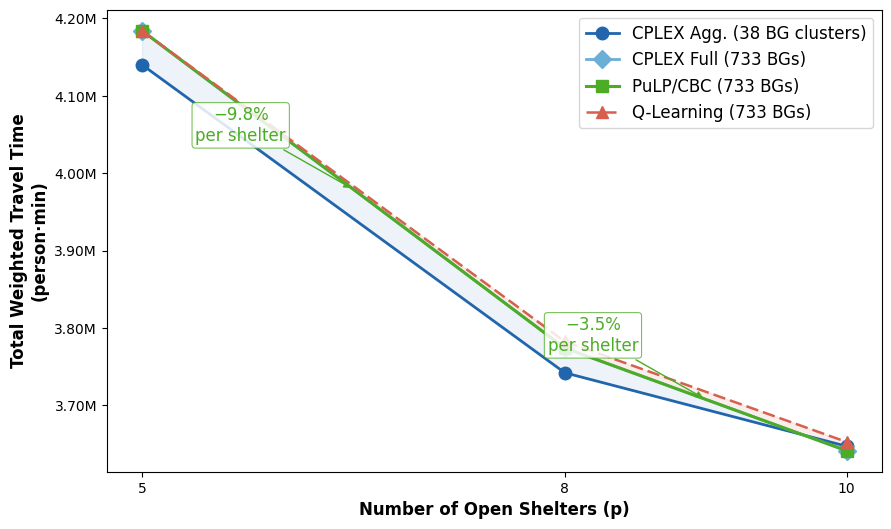

Saved fig4_sensitivity  (4 methods)


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — Figure 4: Sensitivity / marginal improvement  (publication quality, 4 methods)
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))

cf_objs  = [cplex_full_results[p]["objective"] for p in P_VALUES]

# Shaded fill between methods
ax.fill_between(P_VALUES, pl_objs, r_objs,
                alpha=0.10, color=COL["rl"],   label="_nolegend_")
ax.fill_between(P_VALUES, pl_objs, c_objs,
                alpha=0.08, color=COL["cplex"], label="_nolegend_")

ax.plot(P_VALUES, c_objs,  "o-",  color=COL["cplex"],      lw=2,   ms=9,
        label="CPLEX Agg. (38 BG clusters)")
ax.plot(P_VALUES, cf_objs, "D-",  color=COL["cplex_full"], lw=2,   ms=9,
        label="CPLEX Full (733 BGs)")
ax.plot(P_VALUES, pl_objs, "s-",  color=COL["pulp"],       lw=2.2, ms=9,
        label="PuLP/CBC (733 BGs)")
ax.plot(P_VALUES, r_objs,  "^--", color=COL["rl"],         lw=1.8, ms=9,
        label="Q-Learning (733 BGs)", dashes=(5, 2))

# Marginal improvement annotations (PuLP reference)
for i in range(1, len(P_VALUES)):
    imp   = 100*(pl_objs[i-1] - pl_objs[i]) / pl_objs[i-1]
    mid_x = (P_VALUES[i-1] + P_VALUES[i]) / 2
    mid_y = (pl_objs[i-1] + pl_objs[i])   / 2
    ax.annotate(
        f"−{imp:.1f}%\nper shelter",
        xy=(mid_x, mid_y),
        xytext=(mid_x - 0.8, mid_y + pl_objs[0]*0.015),
        fontsize=12, color=COL["pulp"], ha="center",
        arrowprops=dict(arrowstyle="-|>", color=COL["pulp"],
                        lw=1.0, mutation_scale=10),
        bbox=dict(boxstyle="round,pad=0.2", fc="white",
                  ec=COL["pulp"], alpha=0.85, lw=0.7)
    )

ax.set_xticks(P_VALUES)
ax.set_xlabel("Number of Open Shelters (p)", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Weighted Travel Time\n(person·min)", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.legend(fontsize=12)
ax.grid(False)

for fmt in ["pdf", "png"]:
    fig.savefig(os.path.join(output_dir, f"fig4_sensitivity.{fmt}"),
                bbox_inches="tight", dpi=600)
plt.show()
print("Saved fig4_sensitivity  (4 methods)")


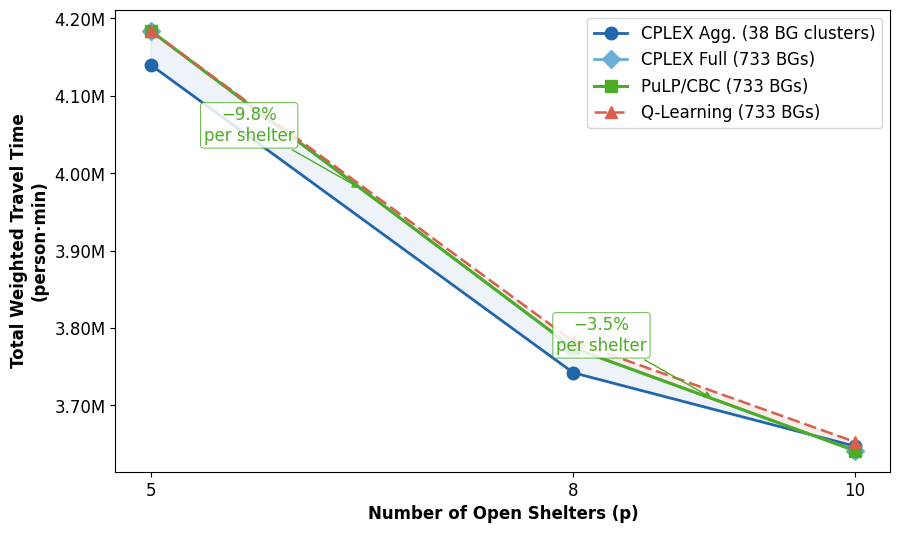

Saved fig4_sensitivity  (4 methods)


In [25]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 — Figure 4: Sensitivity / marginal improvement  (publication quality, 4 methods)
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))

cf_objs  = [cplex_full_results[p]["objective"] for p in P_VALUES]

# Shaded fill between methods
ax.fill_between(P_VALUES, pl_objs, r_objs,
                alpha=0.10, color=COL["rl"],   label="_nolegend_")
ax.fill_between(P_VALUES, pl_objs, c_objs,
                alpha=0.08, color=COL["cplex"], label="_nolegend_")

ax.plot(P_VALUES, c_objs,  "o-",  color=COL["cplex"],       lw=2,   ms=9,
        label="CPLEX Agg. (38 BG clusters)")
ax.plot(P_VALUES, cf_objs, "D-",  color=COL["cplex_full"], lw=2,   ms=9,
        label="CPLEX Full (733 BGs)")
ax.plot(P_VALUES, pl_objs, "s-",  color=COL["pulp"],        lw=2.2, ms=9,
        label="PuLP/CBC (733 BGs)")
ax.plot(P_VALUES, r_objs,  "^--", color=COL["rl"],         lw=1.8, ms=9,
        label="Q-Learning (733 BGs)", dashes=(5, 2))

# Marginal improvement annotations (PuLP reference)
for i in range(1, len(P_VALUES)):
    imp   = 100*(pl_objs[i-1] - pl_objs[i]) / pl_objs[i-1]
    mid_x = (P_VALUES[i-1] + P_VALUES[i]) / 2
    mid_y = (pl_objs[i-1] + pl_objs[i])   / 2
    ax.annotate(
        f"−{imp:.1f}%\nper shelter",
        xy=(mid_x, mid_y),
        xytext=(mid_x - 0.8, mid_y + pl_objs[0]*0.015),
        fontsize=12, color=COL["pulp"], ha="center",
        arrowprops=dict(arrowstyle="-|>", color=COL["pulp"],
                        lw=1.0, mutation_scale=10),
        bbox=dict(boxstyle="round,pad=0.2", fc="white",
                  ec=COL["pulp"], alpha=0.85, lw=0.7)
    )

ax.set_xticks(P_VALUES)
ax.set_xlabel("Number of Open Shelters (p)", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Weighted Travel Time\n(person·min)", fontsize=12, fontweight="bold")

# ---- MODIFICATION: Set tick label sizes to 12 ----
ax.tick_params(axis='both', labelsize=12)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.2f}M"))
ax.legend(fontsize=12)
ax.grid(False)

for fmt in ["pdf", "png", "jpg", "svg"]:
    fig.savefig(os.path.join(output_dir, f"fig4_sensitivity.{fmt}"),
                bbox_inches="tight", dpi=600)
plt.show()
print("Saved fig4_sensitivity  (4 methods)")

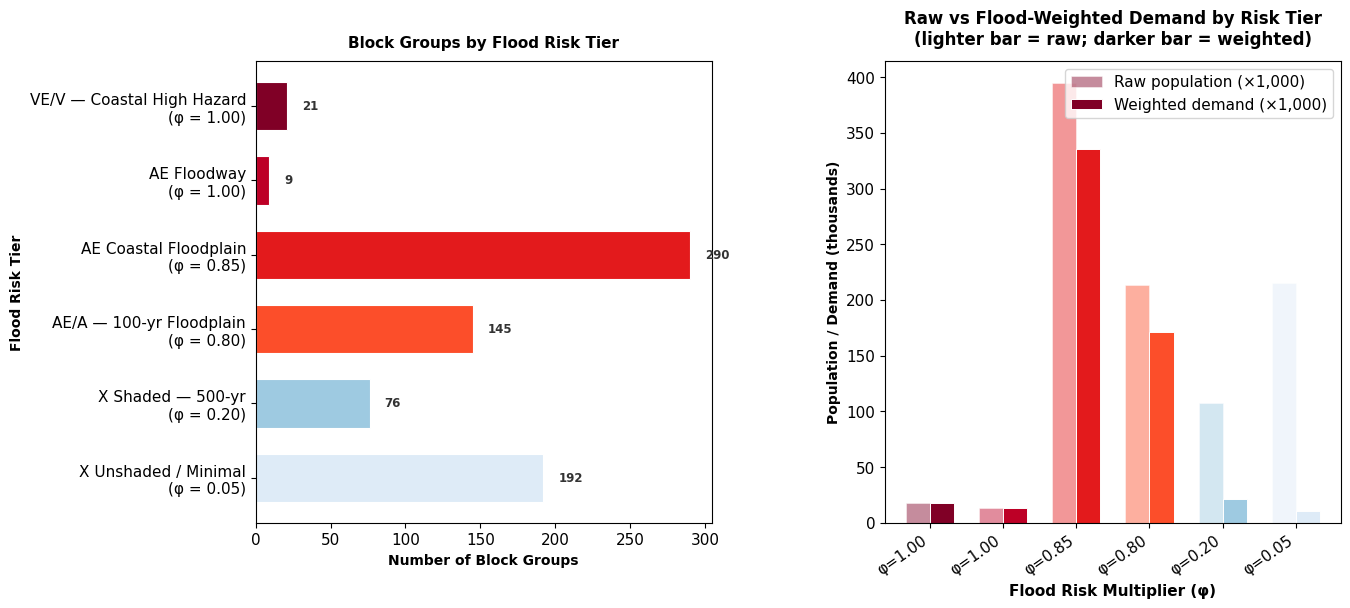

Saved fig5_demand_distribution


In [37]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8 — Figure 5: Flood-risk demand distribution  (publication quality)
# ════════════════════════════════════════════════════════════════════════════
tier_order = [
    "VE/V — Coastal High Hazard", "AE Floodway", "AE Coastal Floodplain",
    "AE/A — 100-yr Floodplain",   "AH/AO — Shallow Flooding",
    "X Shaded — 500-yr",          "X Unshaded / Minimal",
]
tier_colors = {
    "VE/V — Coastal High Hazard": "#800026",
    "AE Floodway":                "#bd0026",
    "AE Coastal Floodplain":      "#e31a1c",
    "AE/A — 100-yr Floodplain":   "#fc4e2a",
    "AH/AO — Shallow Flooding":   "#fd8d3c",
    "X Shaded — 500-yr":          "#9ecae1",
    "X Unshaded / Minimal":       "#deebf7",
}
tier_mult = {
    "VE/V — Coastal High Hazard": 1.00, "AE Floodway": 1.00,
    "AE Coastal Floodplain": 0.85,      "AE/A — 100-yr Floodplain": 0.80,
    "AH/AO — Shallow Flooding": 0.50,   "X Shaded — 500-yr": 0.20,
    "X Unshaded / Minimal": 0.05,
}

tiers = demand.groupby("TIER_LABEL").agg(
    raw_pop   =("POPULATION",      "sum"),
    wtd_demand=("WEIGHTED_DEMAND", "sum"),
    n_bg      =("GEOID_JOIN",      "count")
).reindex([t for t in tier_order if t in demand["TIER_LABEL"].unique()]).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.38)

# ── Left: block group count ──────────────────────────────────────────────────
colors_l = [tier_colors[t] for t in tiers["TIER_LABEL"]]
bars = ax1.barh(range(len(tiers)), tiers["n_bg"],
                color=colors_l, edgecolor="white", linewidth=0.8, height=0.65)
ax1.set_yticks(range(len(tiers)))
ax1.set_yticklabels(
    [f"{t}\n(φ = {tier_mult[t]:.2f})" for t in tiers["TIER_LABEL"]]) # Removed fontsize from here
ax1.invert_yaxis()
ax1.set_xlabel("Number of Block Groups", fontsize=10, fontweight="bold")
ax1.set_ylabel("Flood Risk Tier", fontsize=10, fontweight="bold") # Added y-axis label for ax1
ax1.set_title("Block Groups by Flood Risk Tier", fontsize=11, fontweight="bold", pad=10) # Added pad
ax1.spines["left"].set_visible(True)
ax1.tick_params(left=True, axis='x', labelsize=11) # Set x-axis tick labelsize
ax1.tick_params(axis='y', labelsize=11) # Set y-axis tick labelsize
for bar, val in zip(bars, tiers["n_bg"]):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, # Increased offset
             str(val), va="center", fontsize=8.5, color="#333", fontweight="bold") # Made labels bold

# ── Right: raw vs weighted population ────────────────────────────────────────
x2, bw = np.arange(len(tiers)), 0.33
colors_r = [tier_colors[t] for t in tiers["TIER_LABEL"]]
ax2.bar(x2 - bw/2, tiers["raw_pop"]    / 1000, bw,
        color=colors_r, edgecolor="white", linewidth=0.7, alpha=0.45,
        label="Raw population (×1,000)")
ax2.bar(x2 + bw/2, tiers["wtd_demand"] / 1000, bw,
        color=colors_r, edgecolor="white", linewidth=0.7,
        label="Weighted demand (×1,000)")

ax2.set_xticks(x2)
ax2.set_xticklabels(
    [f"φ={tier_mult[t]:.2f}" for t in tiers["TIER_LABEL"]],
    rotation=35, ha="right") # Removed fontsize from here
ax2.set_xlabel("Flood Risk Multiplier (φ)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Population / Demand (thousands)", fontsize=10, fontweight="bold")
ax2.set_title("Raw vs Flood-Weighted Demand by Risk Tier\n"
              "(lighter bar = raw; darker bar = weighted)",
              fontsize=12, fontweight="bold", pad=12) # Added pad
ax2.legend(fontsize=11, loc="upper right")
ax2.tick_params(axis='x', labelsize=11) # Set x-axis tick labelsize
ax2.tick_params(axis='y', labelsize=11) # Set y-axis tick labelsize

'''fig.suptitle(
    "Flood-Risk-Weighted Demand Structure — Pinellas County, FL\n"
    "7-Tier FEMA-Grounded Multiplier Scheme",
    fontsize=12, fontweight="bold", y=1.01)'''

for fmt in ["pdf", "png"]:
    fig.savefig(os.path.join(output_dir, f"fig5_demand_distribution.{fmt}"))
plt.show()
print("Saved fig5_demand_distribution")

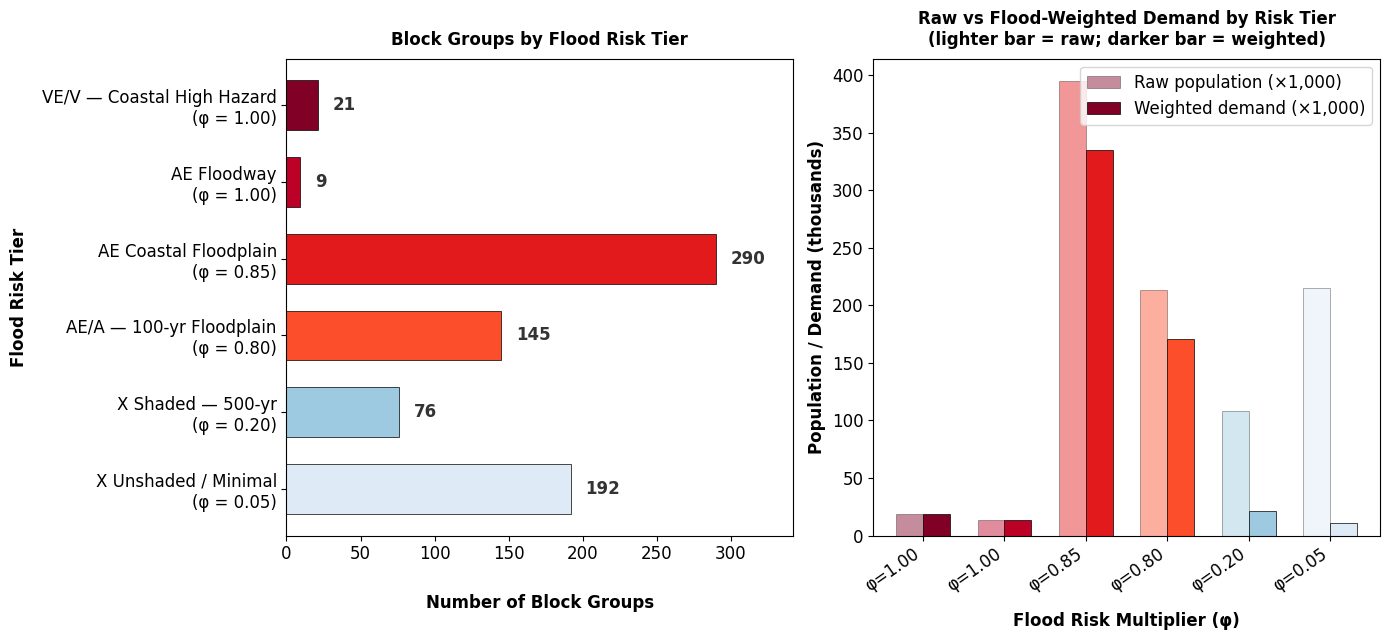

Saved fig5_demand_distribution


In [48]:
import matplotlib.ticker as mticker

# ════════════════════════════════════════════════════════════════════════════
# CELL 8 — Figure 5: Flood-risk demand distribution  (publication quality)
# ════════════════════════════════════════════════════════════════════════════
tier_order = [
    "VE/V — Coastal High Hazard", "AE Floodway", "AE Coastal Floodplain",
    "AE/A — 100-yr Floodplain",   "AH/AO — Shallow Flooding",
    "X Shaded — 500-yr",          "X Unshaded / Minimal",
]
tier_colors = {
    "VE/V — Coastal High Hazard": "#800026",
    "AE Floodway":                "#bd0026",
    "AE Coastal Floodplain":      "#e31a1c",
    "AE/A — 100-yr Floodplain":   "#fc4e2a",
    "AH/AO — Shallow Flooding":   "#fd8d3c",
    "X Shaded — 500-yr":          "#9ecae1",
    "X Unshaded / Minimal":       "#deebf7",
}
tier_mult = {
    "VE/V — Coastal High Hazard": 1.00, "AE Floodway": 1.00,
    "AE Coastal Floodplain": 0.85,      "AE/A — 100-yr Floodplain": 0.80,
    "AH/AO — Shallow Flooding": 0.50,   "X Shaded — 500-yr": 0.20,
    "X Unshaded / Minimal": 0.05,
}

tiers = demand.groupby("TIER_LABEL").agg(
    raw_pop   =("POPULATION",      "sum"),
    wtd_demand=("WEIGHTED_DEMAND", "sum"),
    n_bg      =("GEOID_JOIN",      "count")
).reindex([t for t in tier_order if t in demand["TIER_LABEL"].unique()]).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5)) # Increased figsize
fig.subplots_adjust(wspace=0.5) # Increased wspace

# ── Left: block group count ──────────────────────────────────────────────────
colors_l = [tier_colors[t] for t in tiers["TIER_LABEL"]]
bars = ax1.barh(range(len(tiers)), tiers["n_bg"],
                color=colors_l, edgecolor="black", linewidth=0.5, height=0.65)
ax1.set_yticks(range(len(tiers)))
ax1.set_yticklabels(
    [f"{t}\n(φ = {tier_mult[t]:.2f})" for t in tiers["TIER_LABEL"]])
ax1.invert_yaxis()
ax1.set_xlabel("Number of Block Groups", fontsize=12, fontweight="bold", labelpad=22)
ax1.set_ylabel("Flood Risk Tier", fontsize=12, fontweight="bold", labelpad=10) # Added labelpad
ax1.set_title("Block Groups by Flood Risk Tier", fontsize=12, fontweight="bold", pad=10)
ax1.spines["left"].set_visible(True)
ax1.spines["right"].set_visible(True)
ax1.tick_params(left=True, axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_xlim(right=tiers["n_bg"].max() * 1.18)
for bar, val in zip(bars, tiers["n_bg"]):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=12, color="#333", fontweight="bold")

# ── Right: raw vs weighted population ────────────────────────────────────────
x2, bw = np.arange(len(tiers)), 0.33
colors_r = [tier_colors[t] for t in tiers["TIER_LABEL"]]
ax2.bar(x2 - bw/2, tiers["raw_pop"]    / 1000, bw,
        color=colors_r, edgecolor="black", linewidth=0.5, alpha=0.45,
        label="Raw population (×1,000)")
ax2.bar(x2 + bw/2, tiers["wtd_demand"] / 1000, bw,
        color=colors_r, edgecolor="black", linewidth=0.5,
        label="Weighted demand (×1,000)")

ax2.set_xticks(x2)
ax2.set_xticklabels(
    [f"φ={tier_mult[t]:.2f}" for t in tiers["TIER_LABEL"]],
    rotation=35, ha="right")
ax2.set_xlabel("Flood Risk Multiplier (φ)", fontsize=12, fontweight="bold", labelpad=12) # Added labelpad
ax2.set_ylabel("Population / Demand (thousands)", fontsize=12, fontweight="bold")
ax2.set_title("Raw vs Flood-Weighted Demand by Risk Tier\n"
              "(lighter bar = raw; darker bar = weighted)",
              fontsize=12, fontweight="bold", pad=10)
ax2.legend(fontsize=12, loc="upper right")
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

'''fig.suptitle(
    "Flood-Risk-Weighted Demand Structure — Pinellas County, FL\n"
    "7-Tier FEMA-Grounded Multiplier Scheme",
    fontsize=12, fontweight="bold", y=1.05)''' # Adjusted y for suptitle

plt.tight_layout() # Explicitly call tight_layout
for fmt in ["pdf", "png"]:
    fig.savefig(os.path.join(output_dir, f"fig5_demand_distribution.{fmt}"))
plt.show()
print("Saved fig5_demand_distribution")


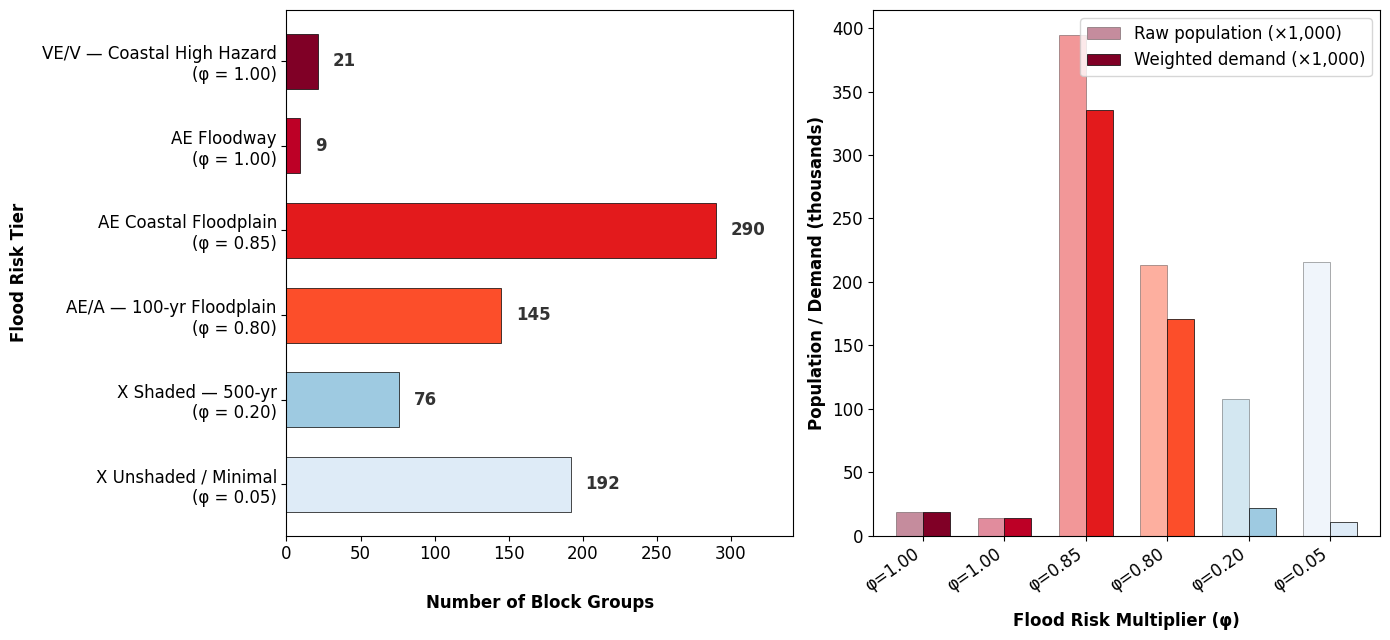

Saved fig5_demand_distribution


In [24]:
import matplotlib.ticker as mticker

# ════════════════════════════════════════════════════════════════════════════
# CELL 8 — Figure 5: Flood-risk demand distribution  (publication quality)
# ════════════════════════════════════════════════════════════════════════════
tier_order = [
    "VE/V — Coastal High Hazard", "AE Floodway", "AE Coastal Floodplain",
    "AE/A — 100-yr Floodplain",   "AH/AO — Shallow Flooding",
    "X Shaded — 500-yr",          "X Unshaded / Minimal",
]
tier_colors = {
    "VE/V — Coastal High Hazard": "#800026",
    "AE Floodway":                "#bd0026",
    "AE Coastal Floodplain":      "#e31a1c",
    "AE/A — 100-yr Floodplain":   "#fc4e2a",
    "AH/AO — Shallow Flooding":   "#fd8d3c",
    "X Shaded — 500-yr":          "#9ecae1",
    "X Unshaded / Minimal":       "#deebf7",
}
tier_mult = {
    "VE/V — Coastal High Hazard": 1.00, "AE Floodway": 1.00,
    "AE Coastal Floodplain": 0.85,      "AE/A — 100-yr Floodplain": 0.80,
    "AH/AO — Shallow Flooding": 0.50,   "X Shaded — 500-yr": 0.20,
    "X Unshaded / Minimal": 0.05,
}

tiers = demand.groupby("TIER_LABEL").agg(
    raw_pop   =("POPULATION",      "sum"),
    wtd_demand=("WEIGHTED_DEMAND", "sum"),
    n_bg      =("GEOID_JOIN",      "count")
).reindex([t for t in tier_order if t in demand["TIER_LABEL"].unique()]).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5)) # Increased figsize
fig.subplots_adjust(wspace=0.5) # Increased wspace

# ── Left: block group count ──────────────────────────────────────────────────
colors_l = [tier_colors[t] for t in tiers["TIER_LABEL"]]
bars = ax1.barh(range(len(tiers)), tiers["n_bg"],
                color=colors_l, edgecolor="black", linewidth=0.5, height=0.65)
ax1.set_yticks(range(len(tiers)))
ax1.set_yticklabels(
    [f"{t}\n(φ = {tier_mult[t]:.2f})" for t in tiers["TIER_LABEL"]])
ax1.invert_yaxis()
ax1.set_xlabel("Number of Block Groups", fontsize=12, fontweight="bold", labelpad=22)
ax1.set_ylabel("Flood Risk Tier", fontsize=12, fontweight="bold", labelpad=10) # Added labelpad
#ax1.set_title("Block Groups by Flood Risk Tier", fontsize=12, fontweight="bold", pad=10)
ax1.spines["left"].set_visible(True)
ax1.spines["right"].set_visible(True)
ax1.tick_params(left=True, axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_xlim(right=tiers["n_bg"].max() * 1.18)
for bar, val in zip(bars, tiers["n_bg"]):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=12, color="#333", fontweight="bold")

# ── Right: raw vs weighted population ────────────────────────────────────────
x2, bw = np.arange(len(tiers)), 0.33
colors_r = [tier_colors[t] for t in tiers["TIER_LABEL"]]
ax2.bar(x2 - bw/2, tiers["raw_pop"]    / 1000, bw,
        color=colors_r, edgecolor="black", linewidth=0.5, alpha=0.45,
        label="Raw population (×1,000)")
ax2.bar(x2 + bw/2, tiers["wtd_demand"] / 1000, bw,
        color=colors_r, edgecolor="black", linewidth=0.5,
        label="Weighted demand (×1,000)")

ax2.set_xticks(x2)
ax2.set_xticklabels(
    [f"φ={tier_mult[t]:.2f}" for t in tiers["TIER_LABEL"]],
    rotation=35, ha="right")
ax2.set_xlabel("Flood Risk Multiplier (φ)", fontsize=12, fontweight="bold", labelpad=12) # Added labelpad
ax2.set_ylabel("Population / Demand (thousands)", fontsize=12, fontweight="bold")
#ax2.set_title("Raw vs Flood-Weighted Demand by Risk Tier\n"
#              "(lighter bar = raw; darker bar = weighted)",
#              fontsize=12, fontweight="bold", pad=10)
ax2.legend(fontsize=12, loc="upper right")
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

'''fig.suptitle(
    "Flood-Risk-Weighted Demand Structure — Pinellas County, FL\n"
    "7-Tier FEMA-Grounded Multiplier Scheme",
    fontsize=12, fontweight="bold", y=1.05)''' # Adjusted y for suptitle

plt.tight_layout() # Explicitly call tight_layout
for fmt in ["pdf", "png", "jpg", "svg"]:
    fig.savefig(os.path.join(output_dir, f"fig5_demand_distribution.{fmt}"))
plt.show()
print("Saved fig5_demand_distribution")


In [51]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9 — Results table + export mapping CSVs
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("FULL RESULTS SUMMARY TABLE")
print("="*80)
print(f"{'p':>4} | {'Method':<18} | {'Objective':>16} | {'Gap vs PuLP':>12} | {'Time(s)':>9}")
print("—"*80)

table_rows = []
for p in P_VALUES:
    c   = cplex_results[p]
    pl  = pulp_results_loaded[p]
    r   = rl_results[p]
    agg = 100*(c["objective"]  - pl["objective"]) / pl["objective"]
    gap = 100*(r["objective"]  - pl["objective"]) / pl["objective"]

    print(f"{p:>4} | {'CPLEX (39 clusters)':<18} | {c['objective']:>16,.2f} | "
          f"{agg:>+11.2f}% | {c['solve_time']:>9.2f}")
    print(f"{p:>4} | {'PuLP/CBC (733 BGs)':<18} | {pl['objective']:>16,.2f} | "
          f"{'— (benchmark)':>12} | {pl['solve_time']:>9.1f}")
    print(f"{p:>4} | {'Q-Learning':<18} | {r['objective']:>16,.2f} | "
          f"{gap:>+11.2f}% | {r['train_time']:>9.1f}")
    print("—"*80)

    for method, res, gap_val in [
        ("CPLEX_clustered", c,  agg),
        ("PuLP_CBC",        pl, 0.0),
        ("Q_Learning",      r,  gap),
    ]:
        # Correctly get the time, handling cases where 'solve_time' is 0.0 or missing 'train_time'
        if "solve_time" in res:
            time_value = res["solve_time"]
        elif "train_time" in res:
            time_value = res["train_time"]
        else:
            time_value = None # Should not happen with current data structure

        table_rows.append({
            "p": p, "Method": method,
            "Objective": round(res["objective"], 2),
            "Gap_vs_PuLP_pct": round(gap_val, 2),
            "Time_s": round(time_value, 1) if time_value is not None else None,
        })

pd.DataFrame(table_rows).to_csv(f"{output_dir}/results_table.csv", index=False)
print("\nSaved: results_table.csv")

# Selected shelters for ArcGIS Pro mapping
map_rows = []
for p in P_VALUES:
    for method, res in [
        ("CPLEX",    cplex_results[p]),
        ("PuLP_CBC", pulp_results_loaded[p]),
        ("RL",       rl_results[p]),
    ]:
        for j in res["selected"]:
            s = candidates.iloc[j]
            map_rows.append({"p":p, "METHOD":method, "SID":j,
                             "NAME":s["NAME"], "LAT":s["LAT"], "LON":s["LON"]})

pd.DataFrame(map_rows).to_csv(f"{output_dir}/selected_shelters_for_mapping.csv", index=False)
print("Saved: selected_shelters_for_mapping.csv")

# Demand assignment CSVs
for p in P_VALUES:
    for method, res in [
        ("CPLEX",    cplex_results[p]),
        ("PuLP_CBC", pulp_results_loaded[p]),
        ("RL",       rl_results[p]),
    ]:
        out = demand[["GEOID_JOIN","LAT","LON","POPULATION","WEIGHTED_DEMAND"]].copy()
        out["ASSIGNED_SID"]    = res["assignments"]
        out["ASSIGNED_NAME"]   = [candidates.iloc[j]["NAME"] for j in res["assignments"]]
        out["TRAVEL_TIME_MIN"] = [D[i, res["assignments"][i]] for i in range(len(demand))]
        out.to_csv(f"{output_dir}/demand_assigned_{method}_p{p}.csv", index=False)

print("All demand assignment CSVs saved.")
print("\nDownload everything and bring back to ArcGIS Pro for map production.")


FULL RESULTS SUMMARY TABLE
   p | Method             |        Objective |  Gap vs PuLP |   Time(s)
————————————————————————————————————————————————————————————————————————————————
   5 | CPLEX (39 clusters) |     4,140,078.06 |       -1.05% |      0.00
   5 | PuLP/CBC (733 BGs) |     4,184,071.38 | — (benchmark) |       7.4
   5 | Q-Learning         |     4,184,071.38 |       +0.00% |     118.6
————————————————————————————————————————————————————————————————————————————————
   8 | CPLEX (39 clusters) |     3,742,283.83 |       -0.85% |      0.00
   8 | PuLP/CBC (733 BGs) |     3,774,238.41 | — (benchmark) |      28.2
   8 | Q-Learning         |     3,782,699.13 |       +0.22% |     121.5
————————————————————————————————————————————————————————————————————————————————
  10 | CPLEX (39 clusters) |     3,647,363.67 |       +0.16% |      0.00
  10 | PuLP/CBC (733 BGs) |     3,641,579.59 | — (benchmark) |      14.2
  10 | Q-Learning         |     3,652,908.77 |       +0.31% |     131.1
———

In [23]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 9 — Results table + export all CSVs  (4 methods)
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "="*82)
print("FULL RESULTS SUMMARY — FOUR METHODS")
print("="*82)
print(f"{'p':>4}  {'Method':<26}  {'Objective':>14}  {'Gap vs PuLP':>12}  {'Time (s)':>9}")
print("—"*82)

table_rows = []
for p in P_VALUES:
    c   = cplex_results[p]
    cf  = cplex_full_results[p]
    pl  = pulp_results_loaded[p]
    r   = rl_results[p]
    agg = 100*(c["objective"]  - pl["objective"]) / pl["objective"]
    cfg = 100*(cf["objective"] - pl["objective"]) / pl["objective"]
    gap = 100*(r["objective"]  - pl["objective"]) / pl["objective"]

    print(f"{p:>4}  {'CPLEX Agg. (38 clusters)':<26}  {c['objective']:>14,.0f}  {agg:>+11.2f}%  {c['solve_time']:>9.2f}")
    print(f"{p:>4}  {'CPLEX Full (733 nodes)':<26}  {cf['objective']:>14,.2f}  {cfg:>+11.4f}%  {cf['solve_time']:>9.2f}")
    print(f"{p:>4}  {'PuLP/CBC (733 BGs)':<26}  {pl['objective']:>14,.0f}  {'— (benchmark)':>12}  {pl['solve_time']:>9.1f}")
    print(f"{p:>4}  {'Q-Learning (733 BGs)':<26}  {r['objective']:>14,.0f}  {gap:>+11.2f}%  {r['train_time']:>9.1f}")
    print("—"*82)

    for method, res, gv in [
        ("CPLEX_clustered",  c,  agg),
        ("CPLEX_Full",       cf, cfg),
        ("PuLP_CBC",         pl, 0.0),
        ("Q_Learning",       r,  gap),
    ]:
        time_value = res.get("solve_time", res.get("train_time"))
        table_rows.append({
            "p":               p,
            "Method":          method,
            "Objective":       round(res["objective"], 2),
            "Gap_vs_PuLP_pct": round(gv, 4),
            "Time_s":          round(time_value, 2),
        })

rt = pd.DataFrame(table_rows)
rt.to_csv(os.path.join(output_dir, "results_table.csv"), index=False)
print(f"\nSaved results_table.csv  ({len(rt)} rows)")

# Selected shelters (all 4 methods)
map_rows = []
for p in P_VALUES:
    for method, res in [("CPLEX_Agg",  cplex_results[p]),
                        ("CPLEX_Full", cplex_full_results[p]),
                        ("PuLP_CBC",   pulp_results_loaded[p]),
                        ("RL",         rl_results[p])]:
        for j in res["selected"]:
            s = candidates.iloc[j]
            map_rows.append({"p":p,"METHOD":method,"SID":j,
                             "NAME":s["NAME"],"LAT":s["LAT"],"LON":s["LON"]})
pd.DataFrame(map_rows).to_csv(
    os.path.join(output_dir, "selected_shelters_for_mapping.csv"), index=False)

# Demand assignments (all 4 methods)
for p in P_VALUES:
    for method, res in [("CPLEX_Agg",  cplex_results[p]),
                        ("CPLEX_Full", cplex_full_results[p]),
                        ("PuLP_CBC",   pulp_results_loaded[p]),
                        ("RL",         rl_results[p])]:
        out = demand[["GEOID_JOIN","LAT","LON","POPULATION","WEIGHTED_DEMAND"]].copy()
        if "TIER_LABEL" in demand.columns:
            out["TIER_LABEL"] = demand["TIER_LABEL"]
        out["ASSIGNED_SID"]    = res["assignments"]
        out["ASSIGNED_NAME"]   = [candidates.iloc[j]["NAME"] for j in res["assignments"]]
        out["TRAVEL_TIME_MIN"] = [D[i, res["assignments"][i]] for i in range(len(demand))]
        out.to_csv(os.path.join(output_dir, f"demand_assigned_{method}_p{p}.csv"), index=False)

print("All outputs saved to:", output_dir)



FULL RESULTS SUMMARY — FOUR METHODS
   p  Method                           Objective   Gap vs PuLP   Time (s)
——————————————————————————————————————————————————————————————————————————————————
   5  CPLEX Agg. (38 clusters)         4,140,078        -1.05%       0.00
   5  CPLEX Full (733 nodes)        4,184,071.38      +0.0000%       1.09
   5  PuLP/CBC (733 BGs)               4,184,071  — (benchmark)        7.4
   5  Q-Learning (733 BGs)             4,184,071        +0.00%      118.7
——————————————————————————————————————————————————————————————————————————————————
   8  CPLEX Agg. (38 clusters)         3,742,284        -0.85%       0.00
   8  CPLEX Full (733 nodes)        3,774,238.41      +0.0000%       1.10
   8  PuLP/CBC (733 BGs)               3,774,238  — (benchmark)       28.2
   8  Q-Learning (733 BGs)             3,782,699        +0.22%      116.3
——————————————————————————————————————————————————————————————————————————————————
  10  CPLEX Agg. (38 clusters)         3,647,3